# Vorrechenübung 3: Finite-Volumen-Methode

Themen dieser Übung sind:
* Diskretisieren der Gleichung für die Finite-Volumen-Methode
    * Unterschied zwischen Finiten Differenzen und Finiten Volumen
    * Approximation des konvektiven Terms mit UDS/CDS
    * Approximation des diffusiven Terms mit CDS
* Verfahrenseigenschaften
    * Konservativität
    * Stabilität

In [1]:
import numpy as np
from helper_functions import plot_heat

In dieser Vorrechenübung wird ein alternatives Verfahren zum Lösen der Aufgabenstellung der vorherigen Vorrechenübung vorgestellt.
Ausgehend von der stationären Konvektions-Diffusions-Gleichung für ein Temperaturfeld wird das Volumenintegral angewandt und mittels Gauß'schem Integralsatz umgeformt:
$$
\frac{\partial}{\partial x_i}(\rho c_p v_i \phi - k \frac{\partial \phi}{\partial x_i}) = Q \\
\sum _c \int _{S_c} (\rho v_i \phi - \alpha \frac{\partial \phi}{\partial x _i}) \boldsymbol{n_{ci}} \, dS_c = \int _V Q \, dV
$$
Die entstehende Gleichung wird nun diskretisiert. Dabei werden der konvektive und der diffusive Term separat voneinander betrachtet. Es wird folgendes **reguläres** Gitter vorausgesetzt:

<p align="center"><img src="Gitter.png" style="width: 25%;"></p>

Zunächst wird der konvektive Term hergeleitet. Hierfür wird der Ostrand als Beispiel genutzt. Zum Lösen des Integrals wird die Mittelpunktregel genutzt:
$$
\int _{S_e} (\rho v_i \phi) n_{ei} \, dS_e \\
 = \rho v_1 \phi _e \cdot \delta S_e
$$
Der Term $\phi _e$ ist der Wert von $\phi$ am rechten Rand des Kontrollvolumens - also zwischen zwei Mittelpunkten benachbarter Kontrollvolumen. Zum bestimmen von $\phi _e$ im konvektiven Term werden zwei mögliche Vorschriften vorgestellt: UDS und CDS.

CDS:
$$
\phi _ e = \phi _E \cdot \gamma _e + \phi _P (1- \gamma _e) \\
\gamma _e = \frac{x_e-x_P}{x_E- x_P}
$$

UDS:
$$
\phi_e = \left\{
    \begin{array}{ll}
    \phi_P & \, \textrm{für } \boldsymbol{n_e} \cdot \rho v > 0  \\
    \phi_E & \, \textrm{für } \boldsymbol{n_e} \cdot \rho v < 0 \\
    \end{array}
    \right.
$$
Wird die Variante "UDS" verwendet und angenommen, dass $\rho v_1 > 0$ gilt, so entsteht folgender Term:
$$
F_e ^C = \rho v_1 \phi _e \cdot \delta S_e = \rho v_1 \phi _P \cdot (y _{ne} -y _{se})
$$
Die Variante "CDS" liefert folgendes Ergebnis:
$$
F_e ^C = \rho v_1 \phi _e \cdot \delta S_e = \frac{1}{2} (\phi _E + \phi _ P) \rho v_1 \cdot (y _{ne} -y _{se})
$$

Der diffusive Term wird mit der Mittelspunktregel und der Variante "CDS" betrachtet. "CDS" entspricht hier der Zentraldifferenz.
$$
\int _{S_c} -\alpha \frac{\partial \phi}{\partial x _1} \boldsymbol{n_{e1}} \, dS_c = - \alpha \frac{\partial \phi _e}{\partial x_1} \cdot \delta S_e \\
\textrm{CDS: } \frac{\partial \phi _e}{\partial x_1} = \frac{\phi _E - \phi _P}{x_E - x_P}\\
F_e ^D = - \alpha \frac{\phi _E - \phi _P}{x_E - x_P} \cdot \delta S_e
$$
Das Ergebnis für den Ostrand ist
$$
\int _{S_e} (\rho v_1 \phi - \alpha \frac{\partial \phi}{\partial x _1}) \boldsymbol{n_{e1}} \, dS_e = F_e ^C + F_e ^D
$$
wobei $F_e^C$ abhängig von der Entscheidung für UDS oder CDS eingesetzt wird.

Der Lastvektor wird mit der Mittelpunktregel folgendermaßen diskretisiert:
$$
\int _V Q \, dV = \Delta x \Delta y Q_P
$$
Das gezeigte Vorgehen am Ostrand wird für alle weiteren Himmelsrichtungen durchgeführt und die resultierende Gleichung wird umgestellt, sodass der Beitrag aller benachbarten Zellen sichtbar ist:
$$
a _S \phi _S + a_W \phi _W + a_P \phi _P + a_E \phi_E + a_N \phi_N = Q_P
$$
Die Koeffizienten $a_c$ sind abhängig von der Entscheidung zwischen UDS und CDS für den konvektiven Term und werden daher für die folgenden Beispiele separat dargestellt.

## Modellparameter

In [2]:
# Model parameters
L_x = 1.0                   # x dimension of the plate in m
L_y = 1.0                   # y dimension of the plate in m
rho = 1.0e3                 # Density of the medium (here: water) in kg/m^3
c_p  = 4.18e3               # heat capacity in J/(kg K)
lambd   = 0.6               # thermal conductivity in W/(m K)
alpha = lambd/(rho*c_p)     # thermal diffusivity in m^2/s
v_1 = 0                     # x speed in m/s
v_2 = 0                     # y speed in m/s

# Grid parameters
N_x = 50                    # Discrete points in x direction
N_y = 50                    # Discrete points in y direction
delta_x = L_x/(N_x-1)       # Step size in x direction in m
delta_y = L_y/(N_y-1)       # Step size in y direction in m
N = N_x * N_y               # Total degrees of freedom
K = np.zeros((N, N))        # Stiffness matrix
f = np.zeros(N)             # Load vector
node_transform = lambda i, j: j*N_x + i  # Conversion from grid index (i, j) to degree of freedom index (I) ( = row in load vector)

##  Konvektiver Term mit UDS
### Innere Punkte
Ausgehend von der Gleichung 
$$
a _S \phi _S + a_W \phi _W + a_P \phi _P + a_E \phi_E + a_N \phi_N = f_P
$$
sowie der oben gezeigten Approximation des konvektiven Terms mit UDS, ergeben sich die Koeffizienten $a_c$ als:
$$
a_S = - \frac{\rho v_2}{\Delta y} - \frac{\alpha}{\Delta y ^2}\\
a_W = - \frac{\rho v_1}{\Delta x} - \frac{\alpha}{\Delta x ^2}\\
a_P = \frac{\rho v_1}{\Delta x} + \frac{2 \alpha}{\Delta x ^2} + \frac{\rho v_2}{\Delta y} + \frac{2 \alpha}{\Delta y ^2}\\
a_E = -\frac{\alpha}{\Delta x^2}\\
a_N = -\frac{\alpha}{\Delta y^2}
$$
Für diese Rechnung wurde jedoch bei der Anwendung des UDS $\rho v_1 > 0$ und $\rho v_2 > 0$ angenommen. Eine geläufige, für beide Strömungsrichtungen funktionierende UDS-Implementierung ist:
$$
a_S = - \textrm{max}(0, \frac{\rho v_2}{\Delta y}) - \frac{\alpha}{\Delta y ^2}\\
a_W = -  \textrm{max}(0, \frac{\rho v_1}{\Delta x}) - \frac{\alpha}{\Delta x ^2}\\
a_N = - \textrm{max}(0, -\frac{\rho v_2}{\Delta y}) - \frac{\alpha}{\Delta y^2}\\
a_E = - \textrm{max}(0, -\frac{\rho v_1}{\Delta x}) - \frac{\alpha}{\Delta x^2}\\
a_P = a_E + a_W + a_N + a_S
$$

In [3]:
# Abbreviations to simplify the code for the coefficients of the stiffness matrix
dfs_x = lambda idx: lambd / (delta_x**2)
dfs_y = lambda idx: lambd / (delta_y**2)
adv_x = lambda idx: rho * c_p * v_1 / delta_x
adv_y = lambda idx: rho * c_p * v_2 / delta_y

# Inner nodes
a_S = lambda idx: dfs_y(idx) + max(0, adv_y(idx))
a_W = lambda idx: dfs_x(idx) + max(0, adv_x(idx))
a_E = lambda idx: dfs_x(idx) + max(0, -adv_x(idx))
a_N = lambda idx: dfs_y(idx) + max(0, -adv_y(idx))
a_P = lambda idx: a_W(idx) + a_E(idx) + a_S(idx) + a_N(idx)

### Randbedingungen
Nachdem die inneren Punkte mittels UDS betrachtet wurden, müssen nun die gegebenen Randbedingungen berücksichtigt werden. Hierfür werden die Kontrollvolumina am Rand des Gebiets separat betrachtet.

<p align="center"> <img src="Rand.png" style="width: 20%;"> </p>

#### Neumann-Randbedingungen
Die Neumann-Randbedingung hat am westlichen Rand des Gebiets die Form 
$$
\frac{\partial \phi}{\partial x_1} \vert _w = q_w
$$
Ausgehend von der anfänglichen Umformung durch den Satz von Gauß
$$
\sum _c \int _{S_c} (\rho v_i \phi - \alpha \frac{\partial \phi}{\partial x _i}) \boldsymbol{n_{ci}} \, dS_c = \int _V Q \, dV
$$
werden nun die zuvor gelösten Integrale erneut betrachtet. Als Beipiel wird diesmal der westliche Rand genommen.

Für den **konvektiven** Term werden nun werden wieder zwei Fälle unterschieden, ausgehend von:
$$
\int _{S_w} (\rho v_i \phi) n_{wi} \, dS_w = \rho v_1 \phi _w \cdot \delta S_w
$$
 - Strömung von Westen nach Osten: Unter Benutzung des gegebenen Stroms am Rand, wird der Wert für $\phi_w$ durch eine lineare Interpolation genähert. Dabei ist insbesondere zu beachten, dass der Abstand zwischen dem Mittelpunkt eines Kontrollvolumens und dem Rand des Gebiets nur halb so groß ist, wie der Abstand zweier Mittelpunkte (vgl. Abbildung).
    $$
        F_w ^C = \rho v_1 \phi _w \cdot \delta S_w\\
        = \rho v_1 (\phi_P - \frac{\partial \phi}{\partial x_1} \vert_w \cdot (x_P-x_w)) \cdot (y _{nw} -y _{sw})\\
        = \rho v_1 (\phi_P - q_w \cdot (x_P-x_w)) \cdot (y _{nw} -y _{sw})\\
    $$
 - Strömung von Osten nach Westen: Es wird $\phi _w = \phi _P$ gesetzt.
        $$
        F_w ^C = \rho v_1 \phi _w \cdot \delta S_w\\
        = \rho v_1 \phi_P \cdot (y _{nw} -y _{sw})
        $$

Für die Herleitung des **diffusiven** Terms kann die gegebene Randbedingung direkt eingesetzt werden.  

$$
\int _{S_c} -\alpha \frac{\partial \phi}{\partial x _1} \boldsymbol{n_{w1}} \, dS_c = - \alpha \frac{\partial \phi}{\partial x_1}\vert _w \cdot \delta S_w = - \alpha q_w \cdot \delta S_e\\
$$

Für den Fall einer Strömung von **Westen nach Osten** erhält man durch Umstellen der Gleichung in die Form
$$
a _S \phi _S + a_W \phi _W + a_P \phi _P + a_E \phi_E + a_N \phi_N = f_P
$$
für $a_N$, $a_E$, $a_S$, $a_P$ die selben Ergebnisse wie bereits für innere Punkte. $a_W$ und $f_P$ werden neu bestimmt: 
    $$
    f_P = Q_P + \frac{q_w}{x_e-x_w}\\
    a_W = 0
    $$

#### Dirichlet-Randbedingungen
Um Dirichlet-Randbedingungen der Form
$$
\phi \vert _w = T_w
$$
zu verwenden, ist die Herleitung sehr ähnlich zu den Neumann-Randbedingungen und wird daher nicht im Detail vorgestellt. Auch hier wird der Einfachheit nur eine Strömung von **Westen nach Osten** betrachtet. Die Koeffizienten $a_N$, $a_E$, $a_S$ sind identisch zu den zuvor für innere Knoten berechneten Werten, da auch hier $v_1 > 0$ angenommen wurde. $a_W$ und $a_P$, sowie $f_P$ werden neu bestimmt: 
    $$
    a_W = 0\\
    a_P = \frac{\rho v_1}{\Delta x} + \frac{\alpha}{\Delta x^2} + \frac{\rho v_2}{\Delta y} + \frac{\alpha}{\Delta y^2}\\
    f_P = Q_P + [\frac{\rho v_1}{\Delta x}+\frac{\alpha}{2 \Delta x^2}]T_w
    $$

Für die Randbedingungen kann wieder analog zu den inneren Punkten eine Schreibweise mit dem $max()$ Operator hergeleitet werden. Diese wird in der Implementierung verwendet.

In [4]:
# Dirichlet boundary condition coefficients
a_P_dirichlet_W = lambda idx: 2*dfs_x(idx) + max(0, adv_x(idx))
a_P_dirichlet_E = lambda idx: 2*dfs_x(idx) + max(0, -adv_x(idx))
a_P_dirichlet_S = lambda idx: 2*dfs_y(idx) + max(0, adv_y(idx))
a_P_dirichlet_N = lambda idx: 2*dfs_y(idx) + max(0, -adv_y(idx))

## Konvektiver Term mit CDS
Einsetzen in die Formel vom Anfang führt auf:
$$
a_S = -\frac{\rho v_2}{2 \Delta y}-\frac{\alpha}{\Delta y ^2}\\
a_W = -\frac{\rho v_1}{2 \Delta x}-\frac{\alpha}{\Delta x ^2}\\
a_P = \frac{\rho v_1}{\Delta x}+\frac{2 \alpha}{\Delta x ^2}+\frac{\rho v_2}{\Delta y}+\frac{2 \alpha}{\Delta y ^2}\\
a_E = -\frac{\rho v_1}{2 \Delta x}-\frac{\alpha}{\Delta x ^2}\\
a_N = -\frac{\rho v_2}{2 \Delta y}-\frac{\alpha}{\Delta y ^2}\\
$$

In [5]:
# Abbreviations to simplify the code for the coefficients of the stiffness matrix
dfs_x = lambda idx: lambd / (delta_x**2)
dfs_y = lambda idx: lambd / (delta_y**2)
adv_x = lambda idx: rho * c_p * v_1 / (2 * delta_x)
adv_y = lambda idx: rho * c_p * v_2 / (2 * delta_y)

# Inner nodes
a_S = lambda idx: dfs_y(idx) + adv_y(idx)
a_W = lambda idx: dfs_x(idx) + adv_x(idx)
a_E = lambda idx: dfs_x(idx) - adv_x(idx)
a_N = lambda idx: dfs_y(idx) - adv_y(idx)
a_P = lambda idx: a_W(idx) + a_E(idx) + a_S(idx) + a_N(idx)

### Randbedingungen
Die Herleitung der Randbedingungen erfolgt, abgesehen von der Fallentscheidung, analog zum UDS und wird daher nicht erneut gezeigt.

In [6]:
# Dirichlet boundary condition coefficients
a_P_dirichlet_W = lambda idx: 2*dfs_x(idx) + adv_x(idx)
a_P_dirichlet_E = lambda idx: 2*dfs_x(idx) - adv_x(idx)
a_P_dirichlet_S = lambda idx: 2*dfs_y(idx) + adv_y(idx)
a_P_dirichlet_N = lambda idx: 2*dfs_y(idx) - adv_y(idx)

## Aufstellen des Gleichungssystems für innere Punkte
Anmerkungen zum gezeigten Vorgehen:
 - Da die Randbedingungen am Rand des betrachteten Gebiets lediglich die Koeffizienten $a_P$ und den seitenspezifischen Koeffizienten (z.B. $a_W$) betreffen, werden die Kontrollvolumina am Rand hier zunächst wie innere Punkte behandelt, wobei die seitenspezifischen Koeffizienten, die $a=0$ sind, ausgelassen werden.
 - Im zweiten Schritt wird die Steifigkeitsmatrix ergänzt, wobei der durch die Randbedingungen geänderte Koeffizienten $a_P$ und $f_P$ ergänzt werden

In [7]:
for j in range(N_y):
    for i in range(N_x):

        p = node_transform(i, j)

        # Disregard a_W on western boundary (a_W = 0 due to BC)
        if i > 0:
            W = node_transform(i-1, j)
            K[p, W] = -a_W(p)
            K[p, p] += a_W(p)

        # east boundary
        if i < N_x-1:
            E = node_transform(i+1, j)
            K[p, E] = -a_E(p)
            K[p, p] += a_E(p)

        # south boundary
        if j > 0:
            S = node_transform(i, j-1)
            K[p, S] = -a_S(p)
            K[p, p] += a_S(p)

        # north boundary
        if j < N_y-1:
            Nn = node_transform(i, j+1)
            K[p, Nn] = -a_N(p)
            K[p, p] += a_N(p)


# Assemble the load vector (here: Heat source)
# Define heat source in spatial coordinates first (dimension N_x x N_y)
source_size = 10                        # dimension of source in number of points per side
Q_0 = 1000                              # heat flux in W
heat_source = np.zeros((N_x, N_y))
heat_source[round(N_x/2-source_size/2):round(N_x/2+source_size/2), round(N_y/2-source_size/2):round(N_y/2+source_size/2)] = Q_0

# Flattening the heat source to be a vector (each row now corresponds to one element)
f = heat_source.flatten()

## Einbinden der Randbedingungen

In [8]:
# bc-order: west, east, south, north
bc_types = ["dirichlet", "neumann", "neumann", "dirichlet"]
T = [300, 300, 300, 300]
q = [0, 0, 0, 0]

# West Boundary
match bc_types[0]:
    case "dirichlet":
        for j in range(N_y):
            p = node_transform(0, j)
            K[p, p] += a_P_dirichlet_W(p)       # Update a_P for Dirichlet BC
            f[p] += a_P_dirichlet_W(p) * T[0]   # Update load vector for Dirichlet BC
    case "neumann":
        for j in range(N_y):
            p = node_transform(0, j)
            f[p] += q[0] / delta_x              # Update load vector for Neumann BC


# East Boundary
match bc_types[1]:
    case "dirichlet":
        for j in range(N_y):
            p = node_transform(N_x-1, j)
            K[p, p] += a_P_dirichlet_E(p)
            f[p] += a_P_dirichlet_E(p) * T[1]
    case "neumann":
        for j in range(N_y):
            p = node_transform(N_x-1, j)
            f[p] += q[1] / delta_x


# South Boundary
match bc_types[2]:
    case "dirichlet":
        for i in range(N_x):
            p = node_transform(i, 0)
            K[p, p] += a_P_dirichlet_S(p)
            f[p] += a_P_dirichlet_S(p) * T[2]
    case "neumann":
        for i in range(N_x):
            p = node_transform(i, 0)
            f[p] += q[2] / delta_y


# North Boundary
match bc_types[3]:
    case "dirichlet":
        for i in range(N_x):
            p = node_transform(i, N_y-1)
            K[p, p] += a_P_dirichlet_N(p)
            f[p] += a_P_dirichlet_N(p) * T[3]
    case "neumann":
        for i in range(N_x):
            p = node_transform(i, N_y-1)
            f[p] += q[3] / delta_y

# Plotten der Ergebnisse

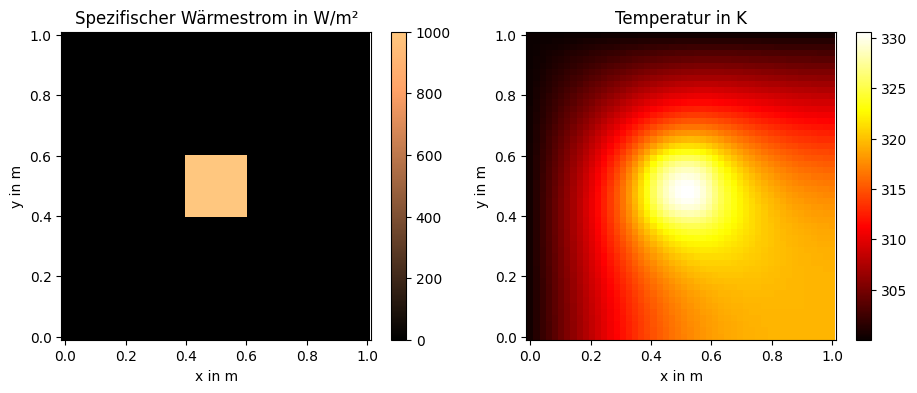

In [9]:
# Solve the system
Phi = np.linalg.solve(K, f)

# Reshape to grid
Phi = Phi.reshape((N_y, N_x))

# Plot the temperature field
x = np.linspace(0, L_x, N_x)
y = np.linspace(0, L_y, N_y)
X, Y = np.meshgrid(x, y)
plot_heat(heat_source, X, Y, Phi)